# Sentiment Analysis Project — Member 2
### Model 1: Naive Bayes (Machine Learning) vs Model 2: LSTM (Deep Learning)

**Dataset note:** `cleaned_data.csv` has columns `cleaned_text` (the input text) and `sentiment`
(the label, as the words `negative` / `neutral` / `positive`). Sentiment distribution: positive
949 (55.6%), negative 691 (40.5%), neutral 67 (3.9%).

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Step 1: Load the dataset

In [10]:
# ===== Step 1: Load the dataset =====

df = pd.read_csv('/content/drive/MyDrive/Project2_SparklingSparkmind/Data/cleaned_data.csv')

df['text'] = df['cleaned_text']

sentiment_to_label = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(sentiment_to_label)

df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

df = df[['text', 'label']].reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nRows per class (0=negative, 1=neutral, 2=positive):")
print(df['label'].value_counts().sort_index())
df.head()


Dataset shape: (1710, 2)

Rows per class (0=negative, 1=neutral, 2=positive):
label
0    691
1     68
2    951
Name: count, dtype: int64


,text,label
0,price misleading show discounted price applyin...,0
1,food bad driver wait hour assign driver eat ti...,0
2,keep good work thank,2
3,shopping made easier fuss returning item best ...,2
4,become complicated reviewing coin macam tak ik...,0


**Note on class balance:** label 1 (neutral) has far fewer rows than labels 0 and 2 (about 4% of
the data). We keep all three classes (per the brief's 3-class framing) but apply balanced
weighting during training and use **stratified** splitting so every
class is represented proportionally in every split.

## Step 2: Split into Train (70%) / Validation (10%) / Test (20%)

In [11]:
# ===== Step 2: Split the data =====

X = df['text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print(f"Train:      {len(X_train):4d} rows ({len(X_train)/len(df):.0%})")
print(f"Validation: {len(X_val):4d} rows ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):4d} rows ({len(X_test)/len(df):.0%})")


Train:      1197 rows (70%)
Validation:  171 rows (10%)
Test:        342 rows (20%)


## Step 3: Model 1 - Naive Bayes (Machine Learning)

In [12]:
# ===== Step 3a: Turn text into numeric features with TF-IDF =====

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)


TF-IDF feature matrix shape (train): (1197, 3699)


In [13]:
# ===== Step 3b: Train the Naive Bayes classifier (with balanced sample weights) =====

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

print("Naive Bayes model trained!")


Naive Bayes model trained!


## Step 4: Evaluation helper (used for BOTH models)

In [18]:
def evaluate_model(y_true, y_pred, model_name):
    """Print accuracy + classification report, and plot a confusion matrix heatmap."""

    acc = accuracy_score(y_true, y_pred)
    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return acc



===== Naive Bayes (Test Set) =====
Accuracy: 0.7690

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77       138
     neutral       0.00      0.00      0.00        14
    positive       0.93      0.85      0.88       190

    accuracy                           0.77       342
   macro avg       0.57      0.53      0.55       342
weighted avg       0.84      0.77      0.80       342



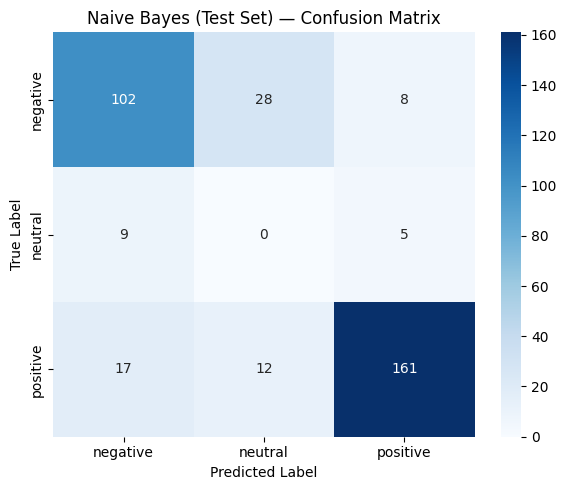

In [19]:
# ===== Evaluate Naive Bayes on the TEST set =====

nb_test_preds = nb_model.predict(X_test_tfidf)                     # predict labels for unseen test text
nb_test_accuracy = evaluate_model(y_test, nb_test_preds, "Naive Bayes (Test Set)")


## Step 5: Model 2 — LSTM (Deep Learning)

In [31]:
# ===== Step 5a: Turn text into padded integer sequences =====

VOCAB_SIZE = 5000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Example — original text:", X_train.iloc[0])
print("Example — padded sequence:", X_train_pad[0])


Example — original text: good experience shopping easy choice available order arrived good condition time overall pleasant shopping experience
Example — padded sequence: [   2   34    3   13  107  208   25  209    2  281    9  145 1109    3
   34    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


In [32]:
# ===== Step 5b: Build the LSTM network =====

EMBEDDING_DIM = 64

lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(units=64),
    Dense(units=3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,219 (1.35 MB)

 Trainable params: 353,219 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ===== Step 5c: Train the LSTM model (with balanced class weights) =====

class_weight_values = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weight_values))
print("Class weights (0=negative, 1=neutral, 2=positive):", class_weight_dict)

history = lstm_model.fit(
    X_train_pad, y_train,                  # training inputs and labels
    validation_data=(X_val_pad, y_val),      # check performance on validation set after every epoch
    epochs=10,                              # number of full passes over the training data
    batch_size=32,                          # number of samples per weight-update step
    class_weight=class_weight_dict,          # give more weight to the underrepresented neutral class
    verbose=1
)


Class weights (0=negative, 1=neutral, 2=positive): {np.int64(0): np.float64(0.8243801652892562), np.int64(1): np.float64(8.48936170212766), np.int64(2): np.float64(0.5990990990990991)}
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5380 - loss: 1.0996 - val_accuracy: 0.5556 - val_loss: 1.0665
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5965 - loss: 0.9403 - val_accuracy: 0.7193 - val_loss: 1.0175
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6449 - loss: 0.8256 - val_accuracy: 0.5088 - val_loss: 0.8651
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7193 - loss: 0.8507 - val_accuracy: 0.5205 - val_loss: 0.9630
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6809 - loss: 0.8851 - val_accuracy: 0.5146 - val_loss: 1.0074
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5915 - loss: 0.8555 - val_accuracy: 0.5263 - val_loss: 0.9520
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - 

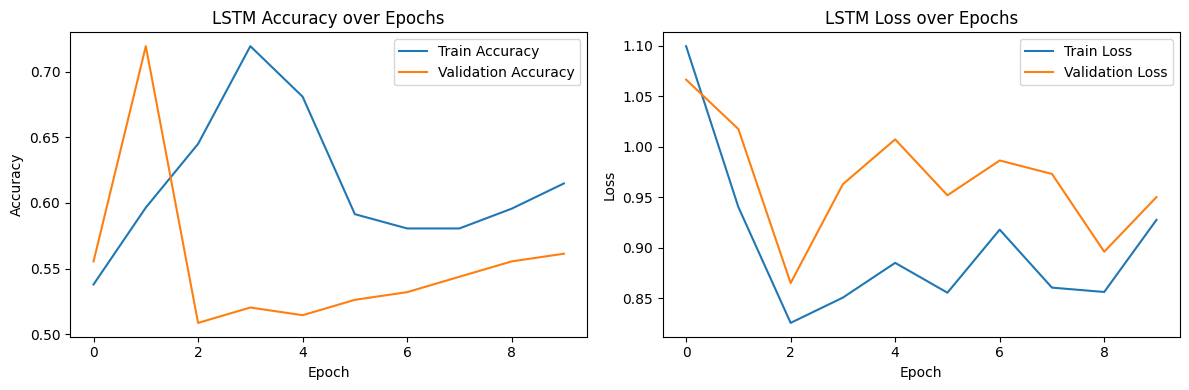

In [34]:
# ===== Plot training curves =====

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('LSTM Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('LSTM Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

===== LSTM (Test Set) =====
Accuracy: 0.5936

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.14      0.23       138
     neutral       0.00      0.00      0.00        14
    positive       0.59      0.97      0.73       190

    accuracy                           0.59       342
   macro avg       0.45      0.37      0.32       342
weighted avg       0.63      0.59      0.50       342



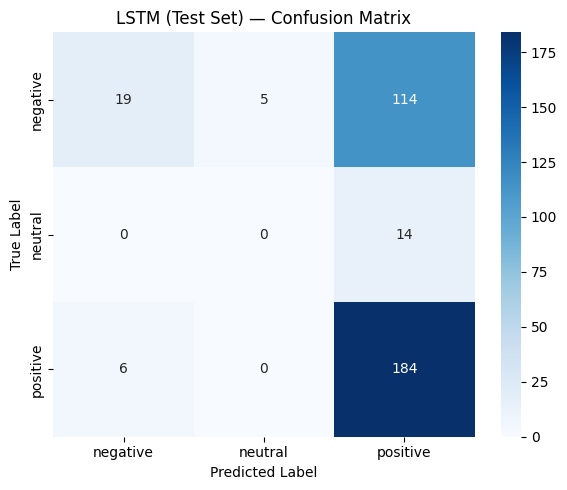

In [35]:
# ===== Step 5d: Evaluate LSTM on the TEST set =====

lstm_test_probs = lstm_model.predict(X_test_pad)
lstm_test_preds = np.argmax(lstm_test_probs, axis=1)

lstm_test_accuracy = evaluate_model(y_test.values, lstm_test_preds, "LSTM (Test Set)")


## Step 6: Compare the two models

In [36]:
# ===== Side-by-side comparison =====
print(f"Naive Bayes Test Accuracy: {nb_test_accuracy:.4f}")
print(f"LSTM        Test Accuracy: {lstm_test_accuracy:.4f}")

Naive Bayes Test Accuracy: 0.7690
LSTM        Test Accuracy: 0.5936


## Step 7: Export both models (for the Spark streaming pipeline)

In [37]:
# ===== Save the Naive Bayes model =====
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump({'model': nb_model, 'vectorizer': tfidf_vectorizer}, f)

print("Saved: naive_bayes_model.pkl  (contains the model AND the vectorizer)")


Saved: naive_bayes_model.pkl  (contains the model AND the vectorizer)


In [38]:
# ===== Save the LSTM model =====
lstm_model.save('lstm_model.keras')

with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Saved: lstm_model.keras")
print("Saved: lstm_tokenizer.pkl  (needed to preprocess new text before using the LSTM)")


Saved: lstm_model.keras
Saved: lstm_tokenizer.pkl  (needed to preprocess new text before using the LSTM)


In [39]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'lstm_tokenizer.pkl', 'naive_bayes_model.pkl', 'drive', 'lstm_model.keras', 'sample_data']


In [40]:
import shutil

dest_folder = '/content/drive/MyDrive/Project2_SparklingSparkmind/models'

import os
os.makedirs(dest_folder, exist_ok=True)   # create the folder if it doesn't exist yet

for fname in ['naive_bayes_model.pkl', 'lstm_model.keras', 'lstm_tokenizer.pkl']:
    shutil.copy(fname, os.path.join(dest_folder, fname))
    print(f"Copied {fname} -> {dest_folder}")

Copied naive_bayes_model.pkl -> /content/drive/MyDrive/Project2_SparklingSparkmind/models
Copied lstm_model.keras -> /content/drive/MyDrive/Project2_SparklingSparkmind/models
Copied lstm_tokenizer.pkl -> /content/drive/MyDrive/Project2_SparklingSparkmind/models


In [41]:
print(os.listdir(dest_folder))

['naive_bayes_model.pkl', 'lstm_model.keras', 'lstm_tokenizer.pkl']
